In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("imports done")

imports done


In [2]:
df = pd.read_csv("../data/paysim.csv")

# keep only customer sender accounts
df = df[df["nameOrig"].str.startswith("C")].copy()

print(f"Transactions from customer accounts: {len(df):,}")
print(f"Unique customer accounts: {df['nameOrig'].nunique():,}")

Transactions from customer accounts: 6,362,620
Unique customer accounts: 6,353,307


In [3]:
# transaction type mix per customer
type_mix = (
    df.groupby(["nameOrig", "type"])
    .size()
    .unstack(fill_value=0)
)
type_mix = type_mix.div(type_mix.sum(axis=1), axis=0)
type_mix.columns = [f"pct_{c.lower()}" for c in type_mix.columns]

# general stats per customer
stats = df.groupby("nameOrig").agg(
    n_transactions=("amount", "count"),
    total_amount=("amount", "sum"),
    avg_amount=("amount", "mean"),
    std_amount=("amount", "std"),
    first_step=("step", "min"),
    last_step=("step", "max"),
)
stats["std_amount"] = stats["std_amount"].fillna(0)
stats["active_span"] = stats["last_step"] - stats["first_step"] + 1

# combine into one profile per customer
profiles = stats.join(type_mix).fillna(0).reset_index()

print(f"Customer profiles built: {len(profiles):,}")
profiles.head()

Customer profiles built: 6,353,307


,nameOrig,n_transactions,total_amount,avg_amount,std_amount,first_step,last_step,active_span,pct_cash_in,pct_cash_out,pct_debit,pct_payment,pct_transfer
0,C1000000639,1,244486.46,244486.46,0.0,249,249,1,0.0,1.0,0.0,0.0,0.0
1,C1000001337,1,3170.28,3170.28,0.0,217,217,1,0.0,0.0,0.0,1.0,0.0
2,C1000001725,1,8424.74,8424.74,0.0,46,46,1,0.0,0.0,0.0,1.0,0.0
3,C1000002591,1,261877.19,261877.19,0.0,231,231,1,1.0,0.0,0.0,0.0,0.0
4,C1000003372,1,20528.65,20528.65,0.0,167,167,1,1.0,0.0,0.0,0.0,0.0


k=2 done
k=3 done
k=4 done
k=5 done
k=6 done
k=7 done
k=8 done


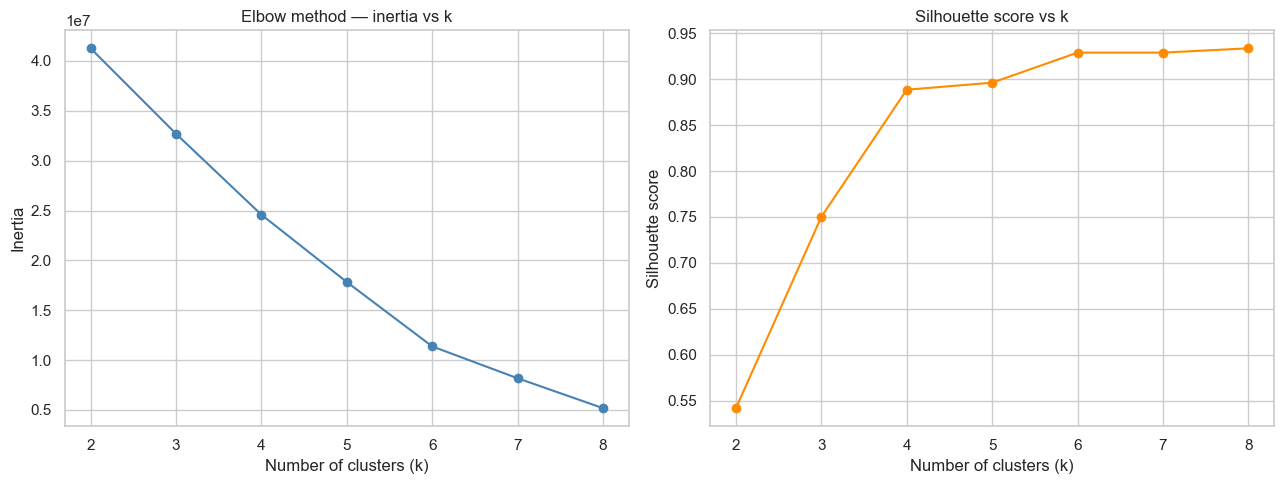

In [4]:
feature_cols = [
    "n_transactions", "avg_amount", "std_amount",
    "pct_cash_in", "pct_cash_out", "pct_payment",
    "pct_transfer", "pct_debit"
]

X = profiles[feature_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=10000, random_state=42))
    print(f"k={k} done")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_range, inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow method — inertia vs k")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_range, silhouettes, marker="o", color="darkorange")
axes[1].set_title("Silhouette score vs k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

In [5]:
CHOSEN_K = 4  # update this based on your plots

km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
profiles["cluster"] = km_final.fit_predict(X_scaled)

print("Cluster sizes:")
print(profiles["cluster"].value_counts().sort_index())

Cluster sizes:
cluster
0    2191574
1    2231800
2    1397326
3     532607
Name: count, dtype: int64


In [6]:
cluster_summary = profiles.groupby("cluster")[feature_cols].mean().round(3)
cluster_summary["n_accounts"] = profiles["cluster"].value_counts().sort_index()
cluster_summary

,n_transactions,avg_amount,std_amount,pct_cash_in,pct_cash_out,pct_payment,pct_transfer,pct_debit,n_accounts
cluster,,,,,,,,,
0,1.002,13073.438,230.654,0.000,0.001,0.98,0.000,0.019,2191574
1,1.001,174915.207,55.995,0.000,1.000,0.00,0.000,0.000,2231800
2,1.002,168923.059,149.953,0.999,0.001,0.00,0.000,0.000,1397326
3,1.002,915533.466,1586.757,0.000,0.001,0.00,0.999,0.000,532607


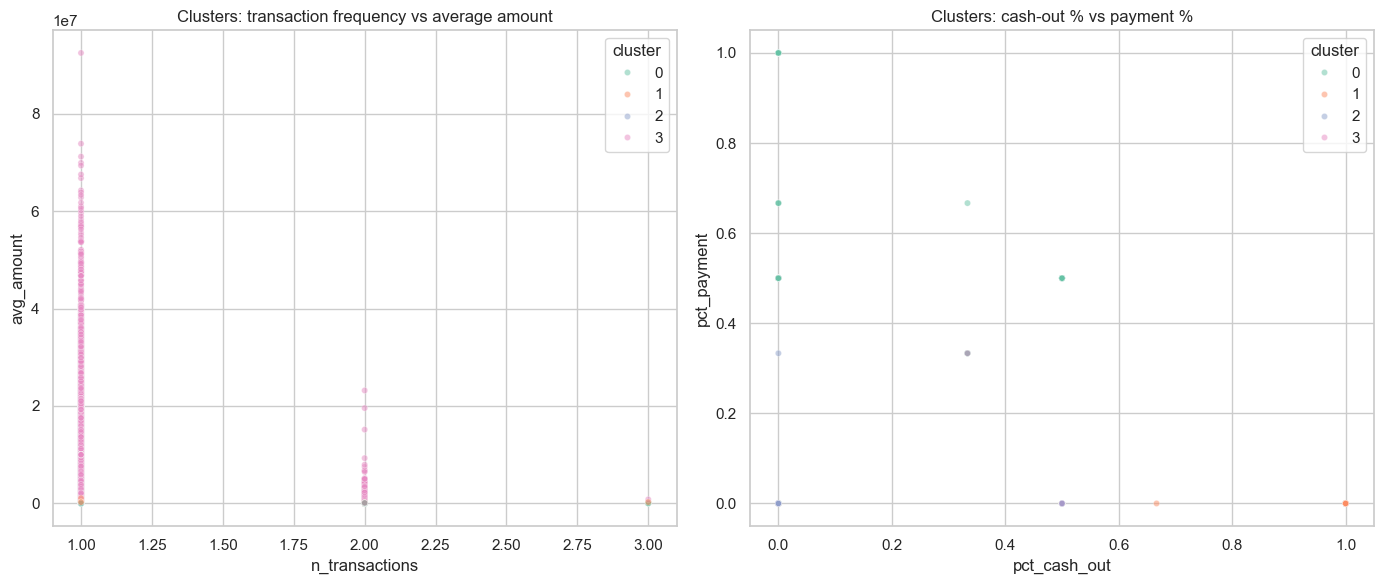

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=profiles, x="n_transactions", y="avg_amount",
    hue="cluster", palette="Set2", s=20, alpha=0.5, ax=axes[0]
)
axes[0].set_title("Clusters: transaction frequency vs average amount")

sns.scatterplot(
    data=profiles, x="pct_cash_out", y="pct_payment",
    hue="cluster", palette="Set2", s=20, alpha=0.5, ax=axes[1]
)
axes[1].set_title("Clusters: cash-out % vs payment %")

plt.tight_layout()
plt.show()